delta = [0.2139 0.3656 0.1549]
Si    = [0.3057 0.4208 0.0025]


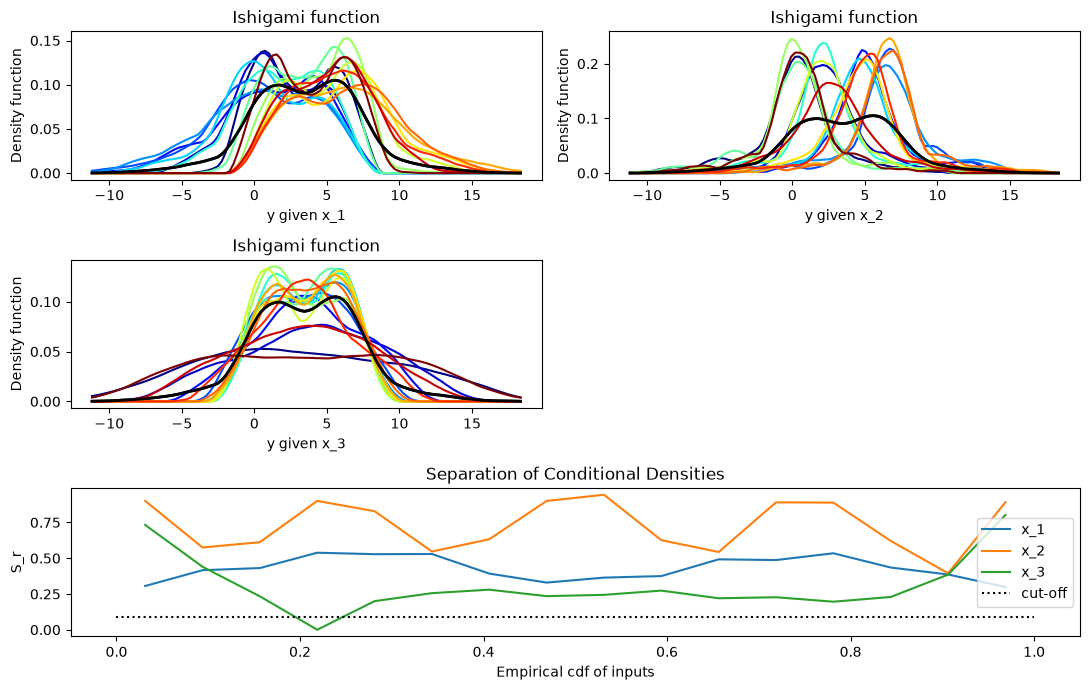

In [3]:
"""
deltamim.py
===========

Python translation of ``deltamim.m`` -- estimation of Borgonovo's delta
moment-independent sensitivity measure from a given (input, output) sample,
with a built-in kernel density estimator.

Reference
---------
Plischke, Borgonovo, Smith:
    "Global sensitivity measures from given data",
    European Journal of Operational Research 226(3):536-550, 2013.

Original MATLAB code by elmar.plischke@tu-clausthal.de.

Notes on the translation
-------------------------
* The core numerical path (default ``KDEstimator='cheap'``) reproduces the
  MATLAB results.  The alternative estimators ``'pilot'``, ``'diffusion'``
  (Botev et al.), ``'nearestneighbor'`` and ``'hist'`` are faithful ports.
* ``'stats'`` in MATLAB relies on the Statistics Toolbox ``ksdensity`` with a
  bounded ``'support'``.  There is no exact NumPy/SciPy equivalent, so it is
  implemented here as a self-contained *reflected* kernel density estimator.
  It is a close approximation but the bounded-support handling differs.
* ``empcdf`` (empirical cdf with tie averaging) is implemented via
  ``scipy.stats.rankdata(method='average')`` which is mathematically identical.
* MATLAB used a ``global Kernel`` to pass the kernel into the density
  estimators; here the kernel callable is passed explicitly.
* Because Python has no ``nargout``, the ``nargout`` keyword selects how many
  outputs are returned (see the docstring of :func:`deltamim`).

Author of the port: converted from the attached MATLAB source.
"""

import numpy as np
from scipy.integrate import trapezoid, cumulative_trapezoid
from scipy.optimize import brentq
from scipy.special import erfinv, gamma as gamma_func
from scipy.stats import rankdata

try:  # SciPy >= 1.4
    from scipy.fft import dct, idct
except ImportError:  # pragma: no cover - very old SciPy
    from scipy.fftpack import dct, idct


# ---------------------------------------------------------------------------
# small helpers
# ---------------------------------------------------------------------------
def _isz(a):
    """True if ``a`` is a (0-d) scalar equal to zero -- mirrors MATLAB ``a==0``."""
    return np.ndim(a) == 0 and a == 0


def empcdf(v):
    """Empirical cdf with tie averaging: ``(rank - 0.5) / n``.

    Equivalent to the MATLAB ``empcdf`` sub-function (which required sorted
    input); ``rankdata`` produces the same average ranks for ties.
    """
    v = np.asarray(v, dtype=float).ravel()
    n = v.size
    return (rankdata(v, method="average") - 0.5) / n


def histc(data, edges):
    """MATLAB ``histc``: counts per bin defined by ``edges``.

    ``counts[i]`` = #{x : edges[i] <= x < edges[i+1]} for i < last, and
    ``counts[-1]`` = #{x : x == edges[-1]}.  Values outside the edges are
    dropped.  Returns an array with ``len(edges)`` entries.
    """
    data = np.asarray(data, dtype=float).ravel()
    edges = np.asarray(edges, dtype=float).ravel()
    m = edges.size
    counts = np.zeros(m)
    idx = np.searchsorted(edges, data, side="right") - 1
    last = edges[-1]
    for v, i in zip(data, idx):
        if v == last:
            counts[m - 1] += 1
        elif 0 <= i < m - 1:
            counts[i] += 1
        # else: out of range -> ignored
    return counts


def make_kernel(shape):
    """Return a kernel callable with unit standard deviation.

    Mirrors the ``switch lower(opts.KDShape)`` block of the MATLAB code.
    """
    shape = str(shape).lower()
    if shape == "normal":
        return lambda x: np.exp(-x ** 2 / 2) / np.sqrt(2 * np.pi)
    if shape == "triangle":
        return lambda x: np.maximum(1 - np.abs(x / np.sqrt(6)), 0) / np.sqrt(6)
    if shape in ("epanechnikov", "parabolic"):
        return lambda x: 3 / (4 * np.sqrt(5)) * np.maximum(1 - (x ** 2 / 5), 0)
    if shape in ("box", "uniform"):
        return lambda x: ((1 - np.abs(x / np.sqrt(3))) > 0).astype(float) / (2 * np.sqrt(3))
    if shape in ("biweight", "biquadratic"):
        return lambda x: 15 / (16 * np.sqrt(7)) * np.maximum(1 - (x ** 2 / 7), 0) ** 2
    raise ValueError("Unsupported kernel")


# ---------------------------------------------------------------------------
# kernel density estimators
# ---------------------------------------------------------------------------
def kdest(y, z, h, kernel):
    """Bowman-Azzalini kernel density estimate of ``y`` evaluated at ``z``.

    Returns ``(est, h)``.  If ``h`` is 0/None the bandwidth is chosen by the
    robust normal-reference rule.
    """
    y = np.asarray(y, dtype=float).ravel()
    z = np.asarray(z, dtype=float).ravel()
    n = y.size
    if h is None or _isz(h):
        m = np.median(y)
        s = min(np.std(y, ddof=1), np.median(np.abs(m - y)) / 0.675)
        h = s / (((3 * n) / 4) ** (1 / 5))
    est = np.mean(kernel((z[None, :] - y[:, None]) / h), axis=0) / h
    return est, h


def kdepilot(y, z, h, kernel):
    """Two-step (pilot) kernel density estimator by Hengartner.

    Returns ``(est, h)``.
    """
    y = np.asarray(y, dtype=float).ravel()
    z = np.asarray(z, dtype=float).ravel()
    n = y.size
    if h is None or _isz(h):
        m = np.median(y)
        s = min(np.std(y, ddof=1), np.median(np.abs(m - y)) / 0.675)
        h = s / (((3 * n) / 4) ** (1 / 5))
    h0 = 1.5 * h
    alfa = np.mean(kernel((y[None, :] - y[:, None]) / h0), axis=0) / h0   # pilot at data (n,)
    est0 = np.mean(kernel((z[None, :] - y[:, None]) / h0), axis=0) / h0   # pilot at eval  (k,)
    K = kernel((z[None, :] - y[:, None]) / h)                            # (n, k)
    est = ((1.0 / alfa) @ K) / (h * n) * est0
    return est, h


def _ksdensity_approx(data, yy, kernel, support, width=0):
    """Approximation of MATLAB ``ksdensity`` with a bounded ``support``.

    Uses boundary reflection across ``L`` and ``U`` to respect the bounded
    support.  This is *not* identical to the Statistics Toolbox implementation
    (which transforms to the whole real line), but is a reasonable stand-in.
    """
    data = np.asarray(data, dtype=float).ravel()
    yy = np.asarray(yy, dtype=float)
    n = data.size
    if width is None or _isz(width):
        m = np.median(data)
        s = min(np.std(data, ddof=1), np.median(np.abs(m - data)) / 0.675)
        h = s / (((3 * n) / 4) ** (1 / 5))
    else:
        h = width
    L, U = support
    ext = np.concatenate([data, 2 * L - data, 2 * U - data])  # reflected sample
    f = np.sum(kernel((yy[:, None] - ext[None, :]) / h), axis=1) / (n * h)
    f[(yy < L) | (yy > U)] = 0.0
    return f


def _fixed_point(t, N, I, a2):
    """Implements ``t - zeta*gamma^[l](t)`` for the diffusion KDE."""
    l = 7
    f = 2 * np.pi ** (2 * l) * np.sum(I ** l * a2 * np.exp(-I * np.pi ** 2 * t))
    for s in range(l - 1, 1, -1):  # s = 6, 5, 4, 3, 2
        K0 = np.prod(np.arange(1, 2 * s, 2)) / np.sqrt(2 * np.pi)  # (2s-1)!!
        const = (1 + (0.5) ** (s + 0.5)) / 3
        time = (2 * const * K0 / N / f) ** (2 / (3 + 2 * s))
        f = 2 * np.pi ** (2 * s) * np.sum(I ** s * a2 * np.exp(-I * np.pi ** 2 * time))
    return t - (2 * N * np.sqrt(np.pi) * f) ** (-2 / 5)


def kde(data, n=2 ** 14, MIN=None, MAX=None, bandwidth_in=None):
    """Reliable diffusion-based 1-D kernel density estimator.

    Port of the Botev / Grotowski / Kroese estimator
    ("Kernel Density Estimation Via Diffusion", Annals of Statistics 2010).

    Returns ``(bandwidth, density, xmesh)``.
    """
    data = np.asarray(data, dtype=float).ravel()
    n = 2 ** int(np.ceil(np.log2(n)))  # round up to next power of two
    if MIN is None or MAX is None:
        mn, mx = data.min(), data.max()
        rng = mx - mn
        if MIN is None:
            MIN = mn - rng / 10
        if MAX is None:
            MAX = mx + rng / 10
    R = MAX - MIN
    xmesh = np.linspace(MIN, MAX, n)
    N = data.size

    initial_data = histc(data, xmesh) / N
    a = dct(initial_data, type=2, norm="ortho")  # MATLAB dct == orthonormal DCT-II
    a = a * np.sqrt(2 * n)
    a[0] = a[0] / np.sqrt(2)                      # convert to the un-normalised scaling

    if bandwidth_in is None:
        I = np.arange(1, n) ** 2.0
        a2 = (a[1:] / 2) ** 2
        t_star = brentq(lambda t: _fixed_point(t, N, I, a2), 0.0, 0.1)
    else:
        t_star = (bandwidth_in / R) ** 2

    a_t = a * np.exp(-np.arange(n) ** 2 * np.pi ** 2 * t_star / 2)
    a_t = a_t / np.sqrt(2 * n)
    a_t[0] = a_t[0] * np.sqrt(2)
    density = idct(a_t, type=2, norm="ortho") / n / R
    bandwidth = np.sqrt(t_star) * R
    return bandwidth, density, xmesh


def densNN(xx, xs, k=None):
    """k-th nearest neighbour density estimate.

    Reference: G. Biau, L. Devroye, "Lectures on the Nearest Neighbor
    Method", Springer 2015.  ``xx`` are the data points, ``xs`` the evaluation
    points.  Returns a 1-D array (scalar ``k``) or a 2-D array (vector ``k``).
    """
    xx = np.asarray(xx, dtype=float)
    xs = np.asarray(xs, dtype=float)
    if xx.ndim == 1:
        xx = xx[:, None]
    if xs.ndim == 1:
        xs = xs[:, None]
    n, d = xx.shape
    m, dd = xs.shape
    scalar_k = (k is None) or (np.ndim(k) == 0)
    if k is None:
        k = int(np.ceil(np.sqrt(n)))
    if d != dd:
        raise ValueError("densNN: Dimension mismatch")
    k = np.atleast_1d(k).astype(int)
    if np.any(k > n):
        raise ValueError("densNN: Out of samples")

    # squared distances (n, m)
    dist = (np.sum(xx * xx, axis=1)[:, None]
            + np.sum(xs * xs, axis=1)[None, :]
            - 2 * xx @ xs.T)
    dist = np.sort(dist, axis=0)          # ascending per evaluation point
    Vd = np.pi ** (d / 2) / gamma_func(d / 2 + 1)
    f = k.reshape(-1, 1) / (n * Vd * dist[k - 1, :] ** (d / 2))  # (len(k), m)
    if scalar_k:
        return f.ravel()
    return f


# ---------------------------------------------------------------------------
# density dispatch used for the marginal (f1) and conditional (f2) densities
# ---------------------------------------------------------------------------
def _estimate(data, yy, alfa, opts, kernel, ysupp, ysupp2, Q, nn_index=0):
    """Compute a density on grid ``yy`` for the selected estimator.

    Returns ``(f, h)`` where ``h`` is the bandwidth (updated for the estimators
    that compute it, otherwise ``alfa`` passed through).
    """
    est = str(opts["KDEstimator"]).lower()
    if est == "cheap":
        return kdest(data, yy, alfa, kernel)
    if est == "pilot":
        return kdepilot(data, yy, alfa, kernel)
    if est == "stats":
        w = 0 if _isz(alfa) else alfa
        return _ksdensity_approx(data, yy, kernel, ysupp, w), alfa
    if est == "diffusion":
        if _isz(alfa):
            h, f, _ = kde(data, Q, ysupp2[0], ysupp2[1])
        else:
            h, f, _ = kde(data, Q, ysupp2[0], ysupp2[1], alfa)
        f = np.asarray(f, dtype=float).copy()
        f[f < 0] = 0.0
        return f, h
    if est == "nearestneighbor":
        if _isz(alfa):
            f = densNN(data, yy)
        else:
            f = densNN(data, yy, int(np.atleast_1d(alfa).ravel()[nn_index]))
        f = f / trapezoid(f, yy)
        return f, alfa
    if est == "hist":
        f0 = histc(data, yy)
        return f0 / trapezoid(f0, yy), alfa
    raise ValueError("Unknown kernel density estimator")


def _kolmog(x, y):
    """Kolmogorov distribution cdf approximation minus level ``y``."""
    if x < 4:
        val = (np.sqrt(2 * np.pi) / x
               * np.sum(np.exp(-(np.arange(1, 36, 2)) ** 2 * np.pi ** 2 / (8 * x ** 2))))
    else:
        val = 1.0
    return val - y


# ---------------------------------------------------------------------------
# main routine
# ---------------------------------------------------------------------------
def deltamim(x, y, M=None, gfx=None, nargout=4, **kwargs):
    """Estimate Borgonovo's delta moment-independent measure.

    Parameters
    ----------
    x : array_like, shape (n, k)
        Input sample (``n`` realisations of ``k`` inputs).  A 1-D array is
        treated as a single input.
    y : array_like, shape (n,)
        Output sample.
    M : int, sequence or dict, optional
        If numeric, the partition size (``PartitionSize``).  If a ``dict`` it
        is treated as an option structure (keys as below).  Pass ``None`` to
        keep defaults (equivalent to MATLAB ``deltamim(x, y, [], ...)``).
    gfx : str, optional
        If given (a non-empty title string), a matplotlib figure is drawn
        (one conditional-density panel per input, plus the separation graph).
        The figure is *drawn* but not displayed -- call
        ``matplotlib.pyplot.show()`` afterwards (or ``savefig``).  See Examples.
    nargout : int, optional
        How many outputs to return, 1..4 (default 4), mirroring MATLAB's
        multiple-output behaviour:

        * 1 -> ``delta``
        * 2 -> ``(delta, Si)``
        * 3 -> ``(delta, Si, acceptL)``
        * 4 -> ``(delta, Si, acceptL, Seps)``
    **kwargs
        Additional options given as key/value pairs.  Recognised option names
        (case-insensitive) mirror the MATLAB defaults:

        ``PartitionSize, QuadraturePoints, KSLevel, ZeroCrossing,
        ParameterNames, KDEstimator, KDWidth, Complement, SwitchXY,
        OutputTrafo, PlotCols, PlotCmd, ShowOpts, ShowSep, KDShape, DDD,
        PowerLoss, PowerLossScale, PartitionSplit, GfxTitle``.

    Returns
    -------
    delta : ndarray, shape (k,)
        Moment-independent delta measure per input.
    Si : ndarray, shape (k,)          (if ``nargout >= 2``)
        First-order (variance-based) effects, biased estimator.
    acceptL : ndarray, shape (3, k)   (if ``nargout >= 3``)
        Predicted acceptance / rejection levels for the KS test.
    Seps : ndarray, shape (k, M)      (if ``nargout >= 4``)
        Conditional separations per input and partition.

    Examples
    --------
    Values only::

        delta, Si = deltamim(X, Y, nargout=2)

    Values *and* a figure (pass a title via ``gfx``, then show it)::

        import matplotlib.pyplot as plt
        delta = deltamim(X, Y, gfx="delta", ParameterNames=["x_1", "x_2"],
                         nargout=1)
        plt.show()
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x[:, None]
    y = np.asarray(y, dtype=float).ravel()
    n, k = x.shape

    # ---- default options -------------------------------------------------
    opts = {
        "PartitionSize": min(int(np.ceil(n ** (2 / (7 + np.tanh((1500 - n) / 500))))), 48),
        "QuadraturePoints": 110,
        "KSLevel": 0.95,
        "ZeroCrossing": "on",
        "ParameterNames": None,
        "KDEstimator": "cheap",
        "KDWidth": "auto",
        "Complement": "off",
        "SwitchXY": "off",
        "OutputTrafo": "off",
        "PlotCols": int(np.ceil(np.sqrt(k))),
        "PlotCmd": "plot",
        "ShowOpts": "off",
        "ShowSep": "on",
        "KDShape": "epanechnikov",
        "DDD": False,
        "PowerLoss": 0,
        "PowerLossScale": 0,
        "PartitionSplit": None,
        "GfxTitle": "",
    }

    def _set(key, val):
        for k0 in opts:
            if k0.lower() == str(key).lower():
                opts[k0] = val
                return

    # ---- argument handling ----------------------------------------------
    if M is not None:
        if isinstance(M, dict):
            for key, val in M.items():
                _set(key, val)
        elif np.ndim(M) == 0:
            opts["PartitionSize"] = int(M)
        else:  # array -> partition size vector (unusual); keep as given
            opts["PartitionSize"] = M
    for key, val in kwargs.items():
        _set(key, val)
    if gfx is None and opts["GfxTitle"]:
        gfx = opts["GfxTitle"]

    # ---- default parameter names ----------------------------------------
    if opts["ParameterNames"] is None:
        pnames = [f"x_{{{i + 1}}}" for i in range(k)] + ["y"]
        opts["ParameterNames"] = pnames
    else:
        pnames = list(opts["ParameterNames"])
        if len(pnames) == k:
            pnames.append("y")
        opts["ParameterNames"] = pnames

    # ---- partition split -------------------------------------------------
    if opts["PartitionSplit"] is not None:
        split = np.asarray(opts["PartitionSplit"], dtype=float).ravel()
        opts["PartitionSize"] = split.size + 1

    if str(opts["KDEstimator"]).lower() == "diffusion":
        opts["QuadraturePoints"] = 2 ** int(np.ceil(np.log2(opts["QuadraturePoints"])))

    # ---- kernel ----------------------------------------------------------
    kernel = make_kernel(opts["KDShape"])

    # ---- critical value for the KS statistic -----------------------------
    KSLevel = np.atleast_1d(np.asarray(opts["KSLevel"], dtype=float))
    full_ks = False
    if not np.all(KSLevel == 0):
        if str(opts["Complement"]).lower() == "on":
            KSLevel = np.abs(KSLevel)                 # complement -> cheap only
        if np.any(KSLevel < 0):
            KSLevel = -KSLevel
            full_ks = True
        KScrit = np.array([brentq(lambda x_: _kolmog(x_, lvl), 0.001, 2.0)
                           for lvl in KSLevel])
    else:
        KScrit = np.array([0.0])
    if KScrit.size == 1:
        KScrit = KScrit * np.ones(k)

    if full_ks:
        def KStest(S, yw, fffw):
            return np.max(np.abs(cumulative_trapezoid(fffw, yw, initial=0)))
    else:
        def KStest(S, yw, fffw):
            return S * 0.5

    if str(opts["ShowOpts"]).lower() != "off":
        print("opts =", opts)

    # ---- output transformation ------------------------------------------
    if callable(opts["OutputTrafo"]):
        y = opts["OutputTrafo"](y)
        opts["OutputTrafo"] = "off"

    indx = np.argsort(y, kind="stable")
    ys = y[indx].astype(float)
    Q = int(opts["QuadraturePoints"])
    ysupp = None

    trafo = str(opts["OutputTrafo"]).lower()
    if trafo in ("off", "none"):
        ymaxmin = ys[[0, -1]]
        rangey = ymaxmin[1] - ymaxmin[0]
        ysupp = ymaxmin + 0.06 * rangey * np.array([-1.0, 1.0])
        yy = np.linspace(ymaxmin[0] - 0.04 * rangey, ymaxmin[1] + 0.04 * rangey, Q)
    elif trafo == "cdf":
        ys = empcdf(ys)
        y = np.empty_like(ys)
        y[indx] = ys
        ysupp = np.array([-0.06, 1.06])
        yy = np.linspace(-0.04, 1.04, Q)
    elif trafo == "normal":
        ncdf = -np.sqrt(2) * erfinv(1 - 2 * empcdf(ys))  # norminv without stats
        y = np.empty_like(ncdf)
        y[indx] = ncdf
        ys = ncdf
        ymaxmin = ys[[0, -1]]
        rangey = ymaxmin[1] - ymaxmin[0]
        ysupp = ymaxmin + 0.06 * rangey * np.array([-1.0, 1.0])
        yy = np.linspace(ymaxmin[0] - 0.04 * rangey, ymaxmin[1] + 0.04 * rangey, Q)
    elif trafo == "interpol":
        from scipy.interpolate import CubicSpline
        xp = (2 * np.arange(1, n + 1) - 1) / (2 * n)
        yy = CubicSpline(xp, ys)(np.linspace(0, 1, Q))
    elif trafo == "cdf-tight":
        ys = empcdf(ys)
        y = np.empty_like(ys)
        y[indx] = ys
        ysupp = np.array([-0.02, 1.02])
        yy = np.linspace(-0.01, 1.01, Q)
    elif trafo == "cdf-loose":
        ys = empcdf(ys)
        y = np.empty_like(ys)
        y[indx] = ys
        ysupp = np.array([-0.1, 1.1])
        yy = np.linspace(-0.08, 1.08, Q)
    else:
        raise ValueError("Unsupported output transformation")

    ysupp2 = yy[[0, -1]]
    yy_grid = yy.copy()

    # ---- transform inputs into (y-ordered) empirical cdf ranks -----------
    xr = np.zeros((n, k))
    consticator = np.zeros(k, dtype=bool)
    for i in range(k):
        col = x[:, i]
        consticator[i] = (col.max() == col.min())
        xr[:, i] = empcdf(col)[indx]

    # ---- marginal (unconditional) density f1 ----------------------------
    alfa = 0 if isinstance(opts["KDWidth"], str) else opts["KDWidth"]
    f1, alfa = _estimate(ys, yy_grid, alfa, opts, kernel, ysupp, ysupp2, Q, nn_index=0)

    # ---- power-loss set-up ----------------------------------------------
    powerloss = opts["PowerLoss"]
    gamma = None
    EfYgm1 = None
    plscale = opts["PowerLossScale"]
    if powerloss != 0:
        gamma = powerloss - 1
        EfYgm1 = trapezoid(f1 ** (gamma + 1), yy_grid)
        if plscale == 0:
            plscale = 2 / gamma / (gamma + 1)

    # ---- partition segments ---------------------------------------------
    Mp = int(opts["PartitionSize"])
    if opts["PartitionSplit"] is None:
        segs = np.linspace(0, 1, Mp + 1)
    else:
        segs = np.concatenate([[0.0], np.asarray(opts["PartitionSplit"], float).ravel(), [1.0]])

    complement = str(opts["Complement"]).lower() == "on"
    zc = str(opts["ZeroCrossing"]).lower()

    # ---- graphics set-up -------------------------------------------------
    plt = None
    ax_dens = {}
    ax_sep = None
    cols = None
    show_sep = str(opts["ShowSep"]).lower()
    layoutrows = 0
    if gfx:
        import matplotlib.pyplot as plt  # noqa: F401
        cols = plt.get_cmap("jet")(np.linspace(0, 1, Mp))  # works on all mpl versions
        fig = plt.gcf()
        fig.clf()
        layoutrows = int(np.ceil(k / opts["PlotCols"]))
        if show_sep == "on":
            layoutrows += 1
        if show_sep == "only":
            layoutrows = 0

    def _plotcmd(ax, xd, yd, *args, **kw):
        return getattr(ax, str(opts["PlotCmd"]))(xd, yd, *args, **kw)

    # ---- outputs ---------------------------------------------------------
    delta = np.zeros(k)
    Seps = np.zeros((k, Mp))
    Si = np.zeros(k) if nargout >= 2 else None
    Ey = np.mean(y) if nargout >= 2 else None
    Vy = np.var(y, ddof=1) if nargout >= 2 else None
    acceptL = np.zeros((3, k)) if nargout >= 3 else None

    # ====================================================================
    # loop over inputs
    # ====================================================================
    for i in range(k):
        if consticator[i]:
            continue  # skip constant input

        Sr = np.zeros(Mp)
        nr = np.zeros(Mp)
        Vyc = np.zeros(Mp) if nargout >= 2 else None
        Kr = np.zeros(Mp) if nargout >= 3 else None

        # density panel set-up
        if gfx and layoutrows > 0:
            ncols = opts["PlotCols"] if k > 1 else 1
            if opts["DDD"]:
                ax = fig.add_subplot(layoutrows, ncols, i + 1, projection="3d")
                ax.plot(yy_grid, 0 * f1, f1, "k", linewidth=2)
                ax.set_zlabel("Density function")
            else:
                ax = fig.add_subplot(layoutrows, ncols, i + 1)
                _plotcmd(ax, yy_grid, f1, "k", linewidth=2)
                ax.set_ylabel("Density function")
            ax.set_xlabel(f"{pnames[k]} given {pnames[i]}")
            ax.set_title(gfx)
            ax_dens[i] = ax

        # ---------------- loop over partitions ---------------------------
        for m in range(Mp):
            if not complement:
                mask = (xr[:, i] >= segs[m]) & (xr[:, i] < segs[m + 1])
            else:
                mask = (xr[:, i] < segs[m]) | (xr[:, i] >= segs[m + 1])
            yx = ys[mask]
            nx = yx.size
            nr[m] = nx
            Sr[m] = 0.0
            if nx <= 0:
                continue

            # contribution to variance of the conditional expectation
            if nargout >= 2:
                if not complement:
                    Vyc[m] = nx * (np.mean(yx) - Ey) ** 2
                else:
                    Vyc[m] = nx ** 2 / (n - nx) * (np.mean(yx) - Ey) ** 2

            # conditional density f2
            alfa_m = 0 if str(opts["KDWidth"]).lower() == "auto" else alfa
            f2, _ = _estimate(yx, yy_grid, alfa_m, opts, kernel, ysupp, ysupp2, Q, nn_index=-1)

            # plot conditional density
            if gfx and layoutrows > 0:
                ax = ax_dens[i]
                if opts["DDD"]:
                    ax.plot(yy_grid, m + 0 * f2, f2, color=cols[m])
                elif not complement:
                    _plotcmd(ax, yy_grid, f2, color=cols[m])
                else:
                    _plotcmd(ax, yy_grid,
                             np.maximum(1 / (n - nx) * (n * f1 - nx * f2), 0),
                             color=cols[m])

            if powerloss != 0:
                Sr[m] = plscale * (trapezoid(f2 ** (gamma + 1), yy_grid) - EfYgm1)
                continue

            # --- density difference ---
            fffw = f1 - f2
            yw = yy_grid
            deltaoffset = 0.0

            if zc == "on":
                ffw = np.abs(fffw)
                deltafactor = 0.5
                ci = np.where(fffw[:-1] * fffw[1:] < 0)[0]  # sign-change (left) indices
                if ci.size:
                    yz = (yy_grid[ci]
                          + (yy_grid[ci + 1] - yy_grid[ci]) * fffw[ci]
                          / (fffw[ci] - fffw[ci + 1]))
                    yw = np.insert(yy_grid, ci + 1, yz)
                    ffw = np.insert(ffw, ci + 1, 0.0)
                    fffw = np.insert(fffw, ci + 1, 0.0)
            elif zc == "positive":
                ffw = np.maximum(fffw, 0)
                deltafactor = 1.0
            elif zc == "negative":
                ffw = -np.minimum(fffw, 0)
                deltafactor = 1.0
            elif zc == "off":
                ffw = np.abs(fffw)
                deltafactor = 0.5
            elif zc == "test":
                ffw = np.concatenate([np.maximum(fffw, 0), -np.minimum(fffw, 0)])
                deltafactor = 0.5
                yw = np.concatenate([yy_grid, yy_grid - yy_grid[0] + yy_grid[-1]])
            elif zc == "min":
                ffw = np.minimum(f1, f2)
                deltafactor = -1.0
                deltaoffset = 2.0
            else:
                print("Unknown ZeroCrossing method")
                ffw = np.abs(fffw)
                deltafactor = 0.5

            if complement:
                ffw = nx / (n - nx) * ffw
                nr[m] = n - nx
                nx = n - nx  # for the KS test below

            # trapezoidal integration
            S = deltaoffset + 2 * deltafactor * trapezoid(ffw, yw)

            # Kolmogorov-Smirnov test (p = KSLevel)
            if KScrit[i] and KStest(S, yw, fffw) < np.sqrt(1 / n + 1 / nx) * KScrit[i]:
                Sr[m] = 0.0
                if nargout >= 2:
                    Vyc[m] = 0.0
            else:
                Sr[m] = S

            if nargout >= 3:
                Kr[m] = np.max(np.abs(cumulative_trapezoid(fffw, yw, initial=0)))

        # ---------------- endogenous rejection level ---------------------
        if nargout >= 3:
            denom = np.sqrt(1 / n + 1 / nr)
            thres1 = np.max(0.5 * Sr / denom)
            thres2 = np.max(Kr / denom)
            thres3 = np.min(Kr / denom)
            if thres1 > 0:
                acceptL[0, i] = _kolmog(thres1, 0)
            if thres2 > 0:
                acceptL[1, i] = _kolmog(thres2, 0)
            if thres3 > 0:
                acceptL[2, i] = _kolmog(thres3, 0)

        # ---------------- finalise density panel -------------------------
        if gfx and layoutrows > 0:
            ax = ax_dens[i]
            if opts["DDD"]:
                ax.plot(yy_grid, 0 * f1 + Mp + 1, f1, "k", linewidth=2)
            else:
                _plotcmd(ax, yy_grid, f1, "k", linewidth=2)

        # ---------------- separation graph -------------------------------
        if gfx and show_sep != "off":
            if ax_sep is None:
                if layoutrows > 0:
                    ax_sep = fig.add_subplot(layoutrows, 1, layoutrows)
                else:
                    ax_sep = fig.add_subplot(1, 1, 1)
            xcols = plt.rcParams["axes.prop_cycle"].by_key()["color"]
            ax_sep.plot(np.cumsum(nr) / n - 1 / (2 * Mp), Sr,
                        color=xcols[i % len(xcols)])

        # ---------------- aggregate over partition segments --------------
        delta[i] = 0.5 * (Sr @ nr) / n
        Seps[i, :] = Sr
        if nargout >= 2:
            Si[i] = np.sum(Vyc) / Vy / (n - 1)

    # ---- finalise separation graph --------------------------------------
    if gfx and show_sep != "off" and ax_sep is not None:
        ax_sep.set_ylabel("S_r")
        ax_sep.set_xlabel("Empirical cdf of inputs")
        ax_sep.set_title("Separation of Conditional Densities")
        if np.all(KScrit != 0):
            q = opts["PartitionSize"]
            ax_sep.plot([0, 1], KScrit[-1] * np.array([1, 1]) * np.sqrt((q + 1) / n), "k:")
            ax_sep.legend(list(pnames[:k]) + ["cut-off"])
        else:
            ax_sep.legend(list(pnames[:k]))

    # ---- return ----------------------------------------------------------
    if nargout == 1:
        return delta
    outs = [delta, Si]
    if nargout >= 3:
        outs.append(acceptL)
    if nargout >= 4:
        outs.append(Seps)
    return tuple(outs)


# ---------------------------------------------------------------------------
# small self-test / demo
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    rng = np.random.default_rng(0)
    N = 4000
    X = rng.uniform(-np.pi, np.pi, size=(N, 3))
    # Ishigami function: x1 and x2 matter, x3 does not (directly)
    a, b = 7.0, 0.1
    Y = np.sin(X[:, 0]) + a * np.sin(X[:, 1]) ** 2 + b * X[:, 2] ** 4 * np.sin(X[:, 0])

    delta, Si = deltamim(X, Y, nargout=2)
    print("delta =", np.round(delta, 4))
    print("Si    =", np.round(Si, 4))

    # ---- plot the conditional densities and the separation graph --------
    # A (non-empty) title in `gfx` triggers the figure; show() displays it.
    import matplotlib.pyplot as plt
    plt.figure(figsize=(11, 7))
    deltamim(X, Y, gfx="Ishigami function",
             ParameterNames=["x_1", "x_2", "x_3"])
    plt.tight_layout()
    plt.show()
